In [138]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zlatan599/mushroom1")

print("Path to dataset files:", path)

Path to dataset files: /home/leo/.cache/kagglehub/datasets/zlatan599/mushroom1/versions/2


In [139]:
import pandas as pd
import os

train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))
val_df = pd.read_csv(os.path.join(path, "val.csv"))

print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)
print("Validation DataFrame shape:", val_df.shape)

print("Train DataFrame columns:", train_df.columns.tolist())
print("Test DataFrame columns:", test_df.columns.tolist())
print("Validation DataFrame columns:", val_df.columns.tolist())

Train DataFrame shape: (689520, 2)
Test DataFrame shape: (15614, 2)
Validation DataFrame shape: (15616, 2)
Train DataFrame columns: ['image_path', 'label']
Test DataFrame columns: ['image_path', 'label']
Validation DataFrame columns: ['image_path', 'label']


In [140]:
# correcting paths in dataframes
train_df['image_path'] = train_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)  
test_df['image_path'] = test_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)
val_df['image_path'] = val_df["image_path"].apply(
    lambda p: os.path.join(path, "/".join(p.split("/")[-3:]))
)

# checking if corrected paths exist
if os.path.exists(train_df['image_path_corrected'].iloc[0]):
    print("Corrected path exists.")
else:
    raise FileNotFoundError("Corrected image path does not exist.")

KeyError: 'image_path_corrected'

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# getting the labels from the training set
train_labels = train_df['label'].value_counts().index
test_labels = test_df['label'].value_counts().index
val_labels = val_df['label'].value_counts().index

print("There are ", len(train_labels), "unique labels in the training set.")
print("There are ", len(test_labels), "unique labels in the test set.")
print("There are ", len(val_labels), "unique labels in the validation set.")

# checking if all labels are the same across train, val, and test sets
if set(train_labels) == set(test_labels) == set(val_labels):
    print("All sets have the same labels.")
    labels = train_labels
else:
    raise ValueError("Labels differ between train, val, and test sets.")


There are  169 unique labels in the training set.
There are  169 unique labels in the test set.
There are  169 unique labels in the validation set.
All sets have the same labels.


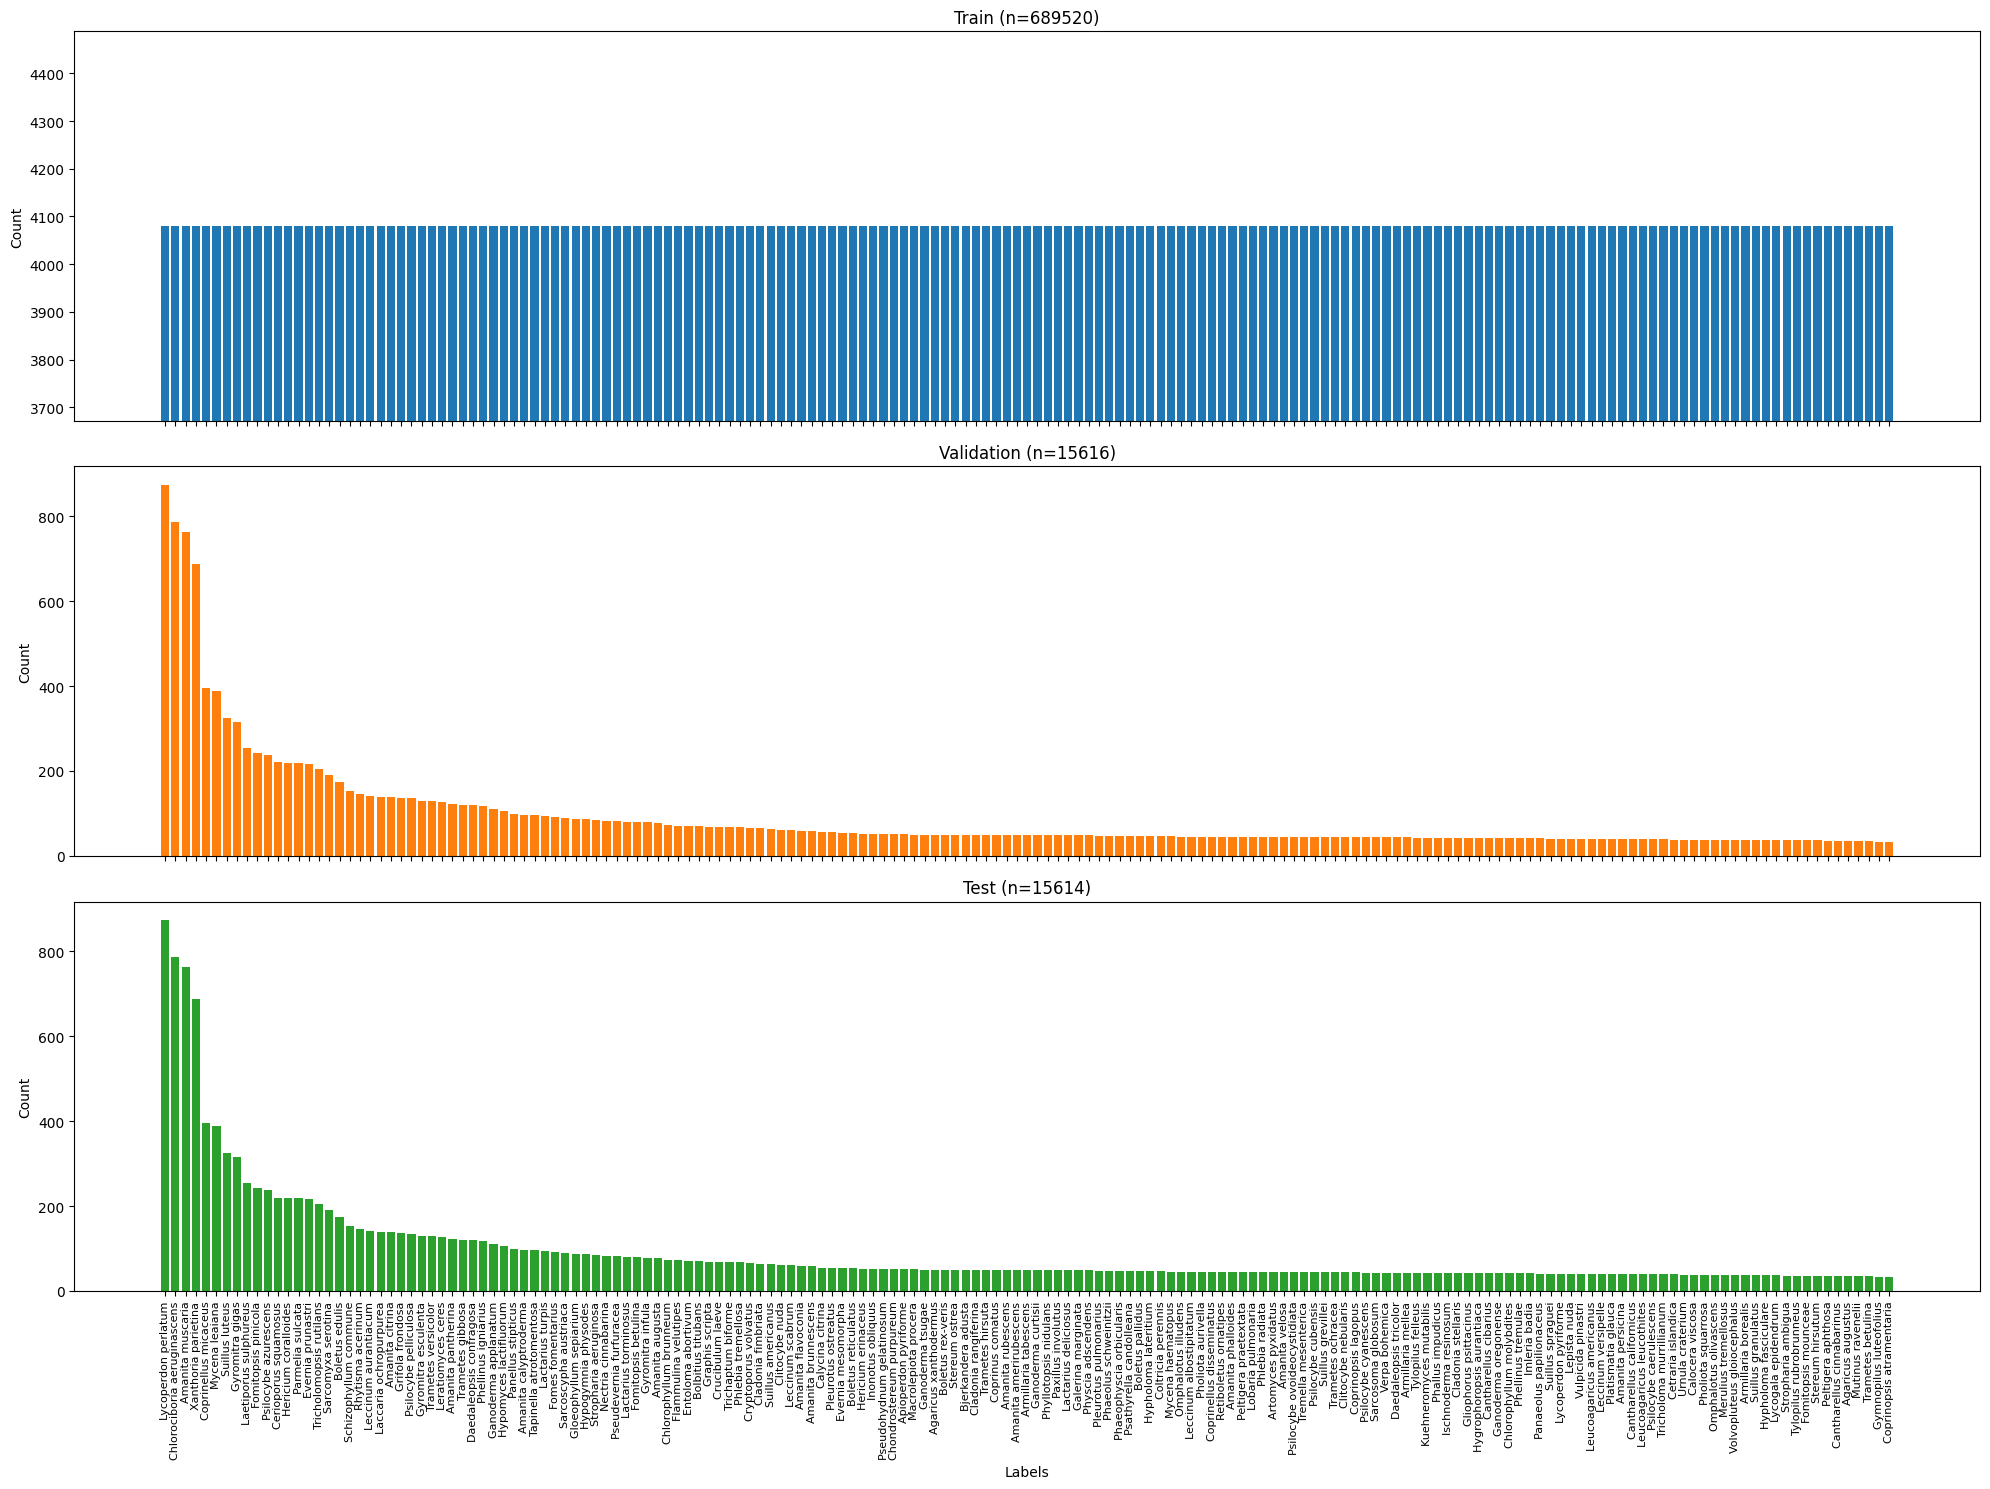

In [ ]:
# calculating counts for each label in train, val, and test sets
counts_train = train_df['label'].value_counts()
counts_val = val_df['label'].value_counts()
counts_test = test_df['label'].value_counts()

x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(20, 15), sharex=True)

axes[0].bar(x, counts_train, color='#1f77b4')
axes[0].set_title(f'Train (n={len(train_df)})')
axes[0].set_ylabel('Count')
# set y-limits for better visualization
axes[0].set_ylim(counts_train.min()*0.9, counts_train.max()*1.1)

axes[1].bar(x, counts_val, color='#ff7f0e')
axes[1].set_title(f'Validation (n={len(val_df)})')
axes[1].set_ylabel('Count')

axes[2].bar(x, counts_test, color='#2ca02c')
axes[2].set_title(f'Test (n={len(test_df)})')
axes[2].set_ylabel('Count')

# setting x-ticks and labels
plt.xticks(x, labels, rotation=90, fontsize=8)
plt.xlabel('Labels')
plt.tight_layout()
plt.show()

In [ ]:
# saving the labels to a .csv file
# if the file already exists, it wont be overwritten
if os.path.exists('labels.csv'):
    print("labels.csv already exists. Not overwriting.")
else:
    labels_df = pd.DataFrame({'label': list(labels)})
    labels_df['edible'] = False
    labels_df.to_csv('labels.csv', index=False)
    print("labels.csv created.")

labels.csv already exists. Not overwriting.


In [ ]:
# after manually adding the 'edible' column by searching online
# and automatically setting false if a species is a lichen or little to none information is found

labels_df = pd.read_csv('labels.csv')

# checking distribution and if there are any issues
counts = labels_df['edible'].value_counts()
print(counts)
print("Any missing label? ", any(labels_df['edible'].isnull()))

edible
False    93
True     76
Name: count, dtype: int64
Any missing label?  False


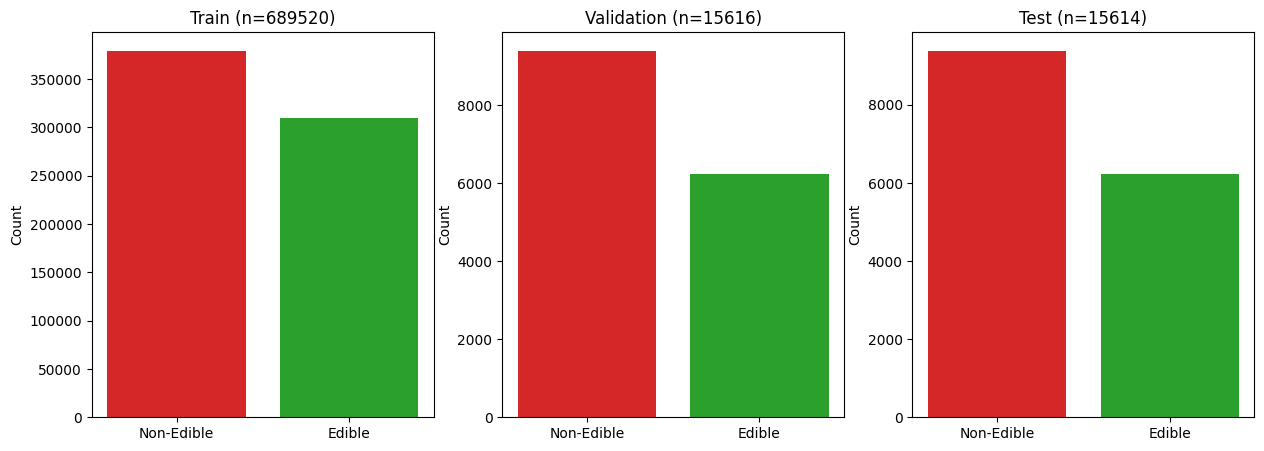

Difference between edible and non-edible:
training set: 69360
validation set: 3168
test set: 3164


In [ ]:
# merging the 'edible' information back to the main dataframes
if 'edible' in train_df.columns:
    print("'edible' column already exists in train_df. Skipping merge.")
else:
    train_df = pd.merge(train_df, labels_df, on='label', how='left')
    val_df = pd.merge(val_df, labels_df, on='label', how='left')
    test_df = pd.merge(test_df, labels_df, on='label', how='left')

# checking for any missing 'edible' values
if train_df['edible'].isnull().any():
    print(train_df.loc[train_df['edible'].isnull(), ['label', 'edible']])
    raise ValueError("Missing 'edible' values in training set after merge.")

edible_counts_train = train_df['edible'].value_counts()
edible_counts_val = val_df['edible'].value_counts()
edible_counts_test = test_df['edible'].value_counts()

# show plot of edible vs non-edible in sets
labels = ['Non-Edible', 'Edible']
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
axes[0].bar(x, [edible_counts_train.get(False, 0), edible_counts_train.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[0].set_title(f'Train (n={len(train_df)})')
axes[0].set_ylabel('Count')
axes[1].bar(x, [edible_counts_val.get(False, 0), edible_counts_val.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[1].set_title(f'Validation (n={len(val_df)})')
axes[1].set_ylabel('Count')
axes[2].bar(x, [edible_counts_test.get(False, 0), edible_counts_test.get(True, 0)], color=['#d62728', '#2ca02c'])
axes[2].set_title(f'Test (n={len(test_df)})')
axes[2].set_ylabel('Count')
plt.xticks(x, labels)
plt.show()

print("Difference between edible and non-edible:")
print("training set:", abs(edible_counts_train.get(True, 0) - edible_counts_train.get(False, 0)))
print("validation set:", abs(edible_counts_val.get(True, 0) - edible_counts_val.get(False, 0)))
print("test set:", abs(edible_counts_test.get(True, 0) - edible_counts_test.get(False, 0)))

# TODO: better balancing the classes and removing some images, 0.7M are too many

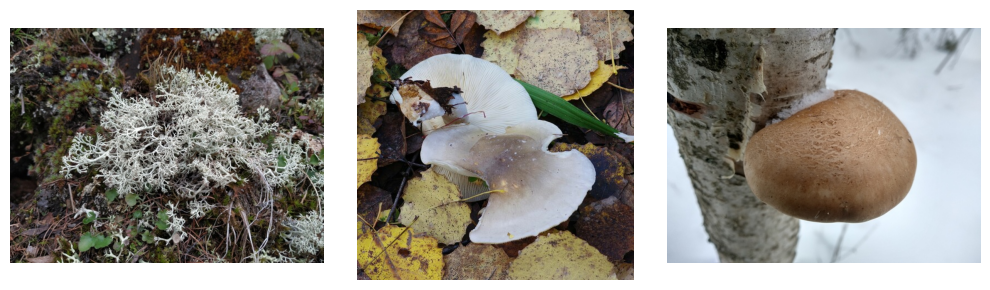

In [ ]:
# randomly display some images from the training set

import random

# Multiple of 3 for better visualization
samples = 6

indicies = random.sample(range(len(train_df)), samples)
images_paths = train_df.iloc[indicies]['image_path'].values

images = []
for img_path in images_paths:
    img = plt.imread(os.path.join(path, img_path))
    images.append(img)

fig, axes = plt.subplots(samples // 3, 3, figsize=(10, 3 * (samples // 3)))
for i, ax in enumerate(axes.flatten()):
    if i < samples:
        ax.imshow(images[i])
    ax.axis('off')
plt.tight_layout()
plt.show()
